In [3]:
# ============================================================
# CELL 1 - IMPORT LIBRARIES AND LOAD DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
df = pd.read_csv(
    "/content/ML_Network_Intrusion_Dataset_Literature_Aligned.csv"
)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (2000, 44)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,label,difficulty_level
0,217,tcp,domain_u,SF,1669,1915,0,0,0,11,...,0.3386,0.2612,0.1075,0.0000,0.0000,0.3701,0.3102,U2R,1,19
1,72,tcp,ssh,S1,1154,495,0,0,0,1,...,0.0984,0.7038,0.3733,0.0000,0.0277,0.0808,0.0000,normal,0,15
2,48,udp,domain_u,REJ,358,271,0,0,0,3,...,0.1244,0.6069,0.1816,0.2728,0.2506,0.5015,0.4338,R2L,1,7
3,68,tcp,private,RSTR,1998,17,0,0,0,3,...,0.4430,0.7417,0.0165,0.2418,0.1774,0.1464,0.2533,Probe,1,3
4,71,tcp,other,RSTO,445,140,0,0,0,4,...,0.0502,0.4608,0.2260,0.0058,0.0506,0.2725,0.3128,R2L,1,2


Dataset Shape:
(2000, 44)

Column Names:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_type', 'label', 'difficulty_level']

Missing Values:
0

Attack Distribution:
attack_type
U2R       400
normal    400
R2L       400
Probe     400
DoS       400
Name: count, dtype: int64


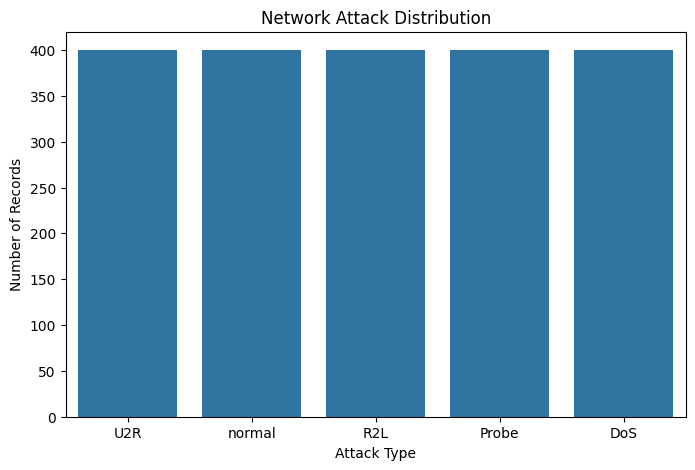

In [4]:
# ============================================================
# CELL 2 - DATASET INFORMATION
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nAttack Distribution:")
print(df["attack_type"].value_counts())

# Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="attack_type"
)

plt.title("Network Attack Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Number of Records")

plt.show()

In [5]:
# ============================================================
# CELL 3 - CUSTOM TRAFFIC BEHAVIOR FEATURES
# ============================================================

# Total network traffic
df["traffic_volume"] = (
    df["src_bytes"] +
    df["dst_bytes"]
)

# Upload/download behavior
df["upload_download_ratio"] = (
    df["src_bytes"] /
    (df["dst_bytes"] + 1)
)

# Connection intensity
df["connection_intensity"] = (
    df["count"] /
    (df["duration"] + 1)
)

# Service error behavior
df["service_error_score"] = (
    df["serror_rate"] +
    df["srv_serror_rate"] +
    df["rerror_rate"] +
    df["srv_rerror_rate"]
) / 4

# Service consistency
df["service_consistency"] = (
    df["same_srv_rate"] -
    df["diff_srv_rate"]
)

# Host anomaly behavior
df["host_anomaly_score"] = (
    df["dst_host_diff_srv_rate"] +
    df["dst_host_srv_diff_host_rate"] +
    df["dst_host_serror_rate"] +
    df["dst_host_rerror_rate"]
) / 4

# Privilege-related activity
df["privilege_activity"] = (
    df["num_compromised"] +
    df["num_root"] +
    df["num_shells"] +
    df["num_file_creations"]
)

# Login risk
df["login_risk"] = (
    df["num_failed_logins"] +
    df["su_attempted"] +
    df["root_shell"]
)

print("New Features Created:")
print([
    "traffic_volume",
    "upload_download_ratio",
    "connection_intensity",
    "service_error_score",
    "service_consistency",
    "host_anomaly_score",
    "privilege_activity",
    "login_risk"
])

display(df.head())

New Features Created:
['traffic_volume', 'upload_download_ratio', 'connection_intensity', 'service_error_score', 'service_consistency', 'host_anomaly_score', 'privilege_activity', 'login_risk']


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,label,difficulty_level,traffic_volume,upload_download_ratio,connection_intensity,service_error_score,service_consistency,host_anomaly_score,privilege_activity,login_risk
0,217,tcp,domain_u,SF,1669,1915,0,0,0,11,...,1,19,3584,0.871086,0.018349,0.145225,0.1374,0.204050,20,1
1,72,tcp,ssh,S1,1154,495,0,0,0,1,...,0,15,1649,2.326613,0.273973,0.049050,0.5345,0.138125,2,0
2,48,udp,domain_u,REJ,358,271,0,0,0,3,...,1,7,629,1.316176,1.000000,0.346600,-0.2271,0.270075,3,0
3,68,tcp,private,RSTR,1998,17,0,0,0,3,...,1,3,2015,111.000000,1.333333,0.260750,-0.5458,0.211925,0,0
4,71,tcp,other,RSTO,445,140,0,0,0,4,...,1,2,585,3.156028,0.319444,0.145350,0.3080,0.138625,1,1


In [6]:
# ============================================================
# CELL 4 - CUSTOM THREAT BEHAVIOR SCORE
# ============================================================

def normalize(series):

    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            0,
            index=series.index
        )

    return (
        (series - minimum) /
        (maximum - minimum)
    )


# Normalize behavioral features
df["traffic_risk"] = normalize(
    df["traffic_volume"]
)

df["error_risk"] = normalize(
    df["service_error_score"]
)

df["host_risk"] = normalize(
    df["host_anomaly_score"]
)

df["login_risk_norm"] = normalize(
    df["login_risk"]
)

df["privilege_risk"] = normalize(
    df["privilege_activity"]
)

df["connection_risk"] = normalize(
    df["connection_intensity"]
)


# Weighted threat score
df["threat_behavior_score"] = (

    0.20 * df["traffic_risk"] +

    0.20 * df["error_risk"] +

    0.15 * df["host_risk"] +

    0.15 * df["login_risk_norm"] +

    0.15 * df["privilege_risk"] +

    0.15 * df["connection_risk"]

) * 100


print("Threat Behavior Score created.")

display(
    df[
        [
            "attack_type",
            "traffic_volume",
            "service_error_score",
            "host_anomaly_score",
            "threat_behavior_score"
        ]
    ].head(10)
)

Threat Behavior Score created.


,attack_type,traffic_volume,service_error_score,host_anomaly_score,threat_behavior_score
0,U2R,3584,0.145225,0.204050,21.681606
1,normal,1649,0.049050,0.138125,5.111514
2,R2L,629,0.346600,0.270075,16.940239
3,Probe,2015,0.260750,0.211925,12.104078
4,R2L,585,0.145350,0.138625,10.757890
5,R2L,242,0.175075,0.174750,16.198274
6,Probe,1166,0.303900,0.195350,17.170144
7,U2R,8153,0.102775,0.097550,17.603365
8,normal,654,0.032500,0.171200,5.352880
9,R2L,2072,0.418950,0.393275,31.171205


Threat Level Distribution:
threat_level
LOW       1912
MEDIUM      88
Name: count, dtype: int64


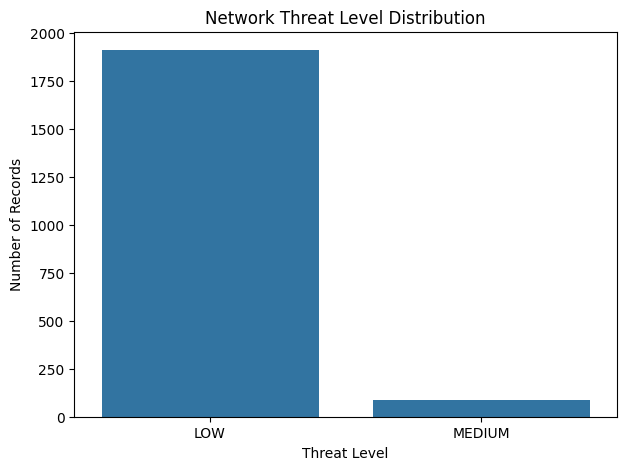

In [7]:
# ============================================================
# CELL 5 - THREAT LEVEL CLASSIFICATION
# ============================================================

def threat_level(score):

    if score < 30:
        return "LOW"

    elif score < 60:
        return "MEDIUM"

    else:
        return "HIGH"


df["threat_level"] = (
    df["threat_behavior_score"]
    .apply(threat_level)
)


print("Threat Level Distribution:")

print(
    df["threat_level"]
    .value_counts()
)


plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="threat_level"
)

plt.title("Network Threat Level Distribution")
plt.xlabel("Threat Level")
plt.ylabel("Number of Records")

plt.show()

Threat Score Statistics:


,traffic_volume,upload_download_ratio,connection_intensity,service_error_score,host_anomaly_score,privilege_activity,login_risk,threat_behavior_score
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,4708.37,41.81,2.68,0.27,0.25,4.85,0.40,17.59
std,7061.07,295.42,12.58,0.16,0.09,5.73,0.67,7.66
min,123.00,0.00,0.00,0.00,0.04,0.00,0.00,1.31
25%,1196.25,0.35,0.15,0.13,0.17,1.00,0.00,11.85
50%,2437.00,2.43,0.49,0.25,0.24,2.00,0.00,17.84
75%,5279.00,18.14,1.48,0.38,0.31,7.00,1.00,23.15
max,76276.00,11966.67,265.00,0.74,0.60,34.00,4.00,48.85


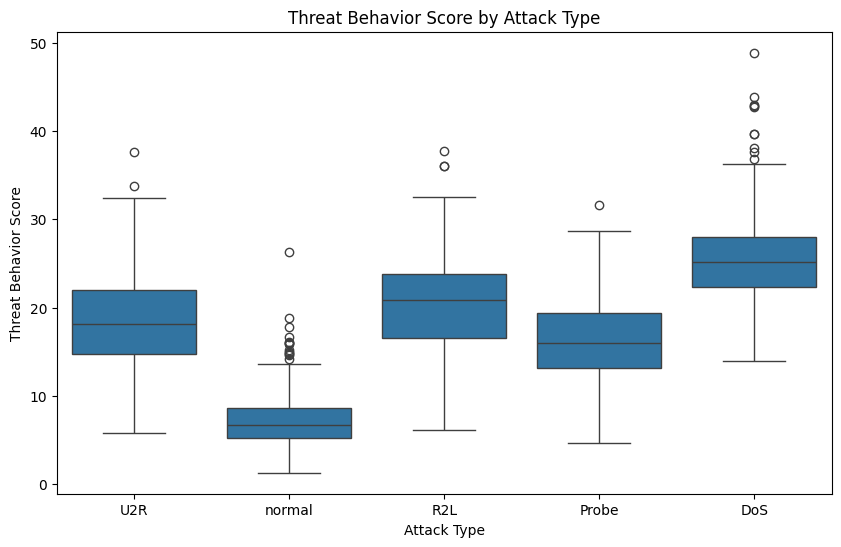

In [8]:
# ============================================================
# CELL 6 - THREAT SCORE ANALYSIS
# ============================================================

print("Threat Score Statistics:")

display(
    df[
        [
            "traffic_volume",
            "upload_download_ratio",
            "connection_intensity",
            "service_error_score",
            "host_anomaly_score",
            "privilege_activity",
            "login_risk",
            "threat_behavior_score"
        ]
    ].describe().round(2)
)


plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="attack_type",
    y="threat_behavior_score"
)

plt.title(
    "Threat Behavior Score by Attack Type"
)

plt.xlabel("Attack Type")

plt.ylabel(
    "Threat Behavior Score"
)

plt.show()

In [9]:
# ============================================================
# CELL 7 - PREPARE DATA
# ============================================================

target = "attack_type"

# Columns that should not be used as input
drop_columns = [
    "attack_type",
    "label",
    "difficulty_level",
    "threat_level"
]

X = df.drop(
    columns=drop_columns
)

y = df[target]


# Find categorical columns
categorical_features = (
    X.select_dtypes(
        include=["object"]
    ).columns.tolist()
)


# Find numerical columns
numerical_features = (
    X.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()
)


print(
    "Number of Input Features:",
    X.shape[1]
)

print(
    "\nCategorical Features:",
    categorical_features
)

print(
    "\nNumber of Numerical Features:",
    len(numerical_features)
)

Number of Input Features: 56

Categorical Features: ['protocol_type', 'service', 'flag']

Number of Numerical Features: 53


In [10]:
# ============================================================
# CELL 8 - TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("Training Samples:", X_train.shape[0])

print("Testing Samples:", X_test.shape[0])

print("\nTraining Class Distribution:")

print(
    y_train.value_counts()
)

print("\nTesting Class Distribution:")

print(
    y_test.value_counts()
)

Training Samples: 1600
Testing Samples: 400

Training Class Distribution:
attack_type
Probe     320
R2L       320
DoS       320
U2R       320
normal    320
Name: count, dtype: int64

Testing Class Distribution:
attack_type
normal    80
U2R       80
Probe     80
DoS       80
R2L       80
Name: count, dtype: int64


In [11]:
# ============================================================
# CELL 9 - DATA PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",

            StandardScaler(),

            numerical_features
        ),

        (
            "cat",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),

            categorical_features
        )
    ]
)


print("Preprocessing pipeline created.")

print(
    "Numerical Features:",
    len(numerical_features)
)

print(
    "Categorical Features:",
    len(categorical_features)
)

Preprocessing pipeline created.
Numerical Features: 53
Categorical Features: 3


In [12]:
# ============================================================
# CELL 10 - RANDOM FOREST
# ============================================================

rf_pipeline = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",

            RandomForestClassifier(

                n_estimators=300,

                max_depth=18,

                min_samples_split=4,

                random_state=42,

                class_weight="balanced"

            )
        )
    ]
)


print("Training Random Forest...")

rf_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest Training Completed!")

Training Random Forest...
Random Forest Training Completed!


In [13]:
# ============================================================
# CELL 11 - RANDOM FOREST EVALUATION
# ============================================================

rf_pred = rf_pipeline.predict(
    X_test
)

rf_prob = rf_pipeline.predict_proba(
    X_test
)


rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)


print("========== RANDOM FOREST ==========")

print(
    "Accuracy :",
    round(rf_accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(rf_precision * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(rf_recall * 100, 2),
    "%"
)

print(
    "F1 Score :",
    round(rf_f1 * 100, 2),
    "%"
)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

========== RANDOM FOREST ==========
Accuracy : 96.5 %
Precision: 96.51 %
Recall   : 96.5 %
F1 Score : 96.5 %

Classification Report:
              precision    recall  f1-score   support

         DoS       0.99      0.99      0.99        80
       Probe       0.97      0.96      0.97        80
         R2L       0.93      0.93      0.93        80
         U2R       0.94      0.95      0.94        80
      normal       1.00      1.00      1.00        80

    accuracy                           0.96       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.96      0.97       400



In [15]:
# ============================================================
# CELL 12 - PREPARE DATA FOR DNN
# ============================================================

# Fit preprocessing
X_train_processed = (
    preprocessor.fit_transform(
        X_train
    )
)

X_test_processed = (
    preprocessor.transform(
        X_test
    )
)


# Encode attack classes
label_encoder = LabelEncoder()

y_train_encoded = (
    label_encoder.fit_transform(
        y_train
    )
)

y_test_encoded = (
    label_encoder.transform(
        y_test
    )
)


num_classes = len(
    label_encoder.classes_
)


print(
    "DNN Input Features:",
    X_train_processed.shape[1]
)

print(
    "\nAttack Classes:"
)

print(
    label_encoder.classes_
)

DNN Input Features: 70

Attack Classes:
['DoS' 'Probe' 'R2L' 'U2R' 'normal']


In [16]:
# ============================================================
# CELL 13 - DEEP NEURAL NETWORK
# ============================================================

dnn = Sequential([

    Dense(
        128,
        activation="relu",
        input_shape=(
            X_train_processed.shape[1],
        )
    ),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        num_classes,
        activation="softmax"
    )
])


dnn.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)


dnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,589 (76.52 KB)

 Trainable params: 19,589 (76.52 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# ============================================================
# CELL 14 - TRAIN DNN
# ============================================================

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True
)


print("Training Deep Neural Network...")


history = dnn.fit(

    X_train_processed,

    y_train_encoded,

    validation_split=0.20,

    epochs=50,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)


print("DNN Training Completed!")

Training Deep Neural Network...
Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5727 - loss: 1.1315 - val_accuracy: 0.7937 - val_loss: 0.5938
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8633 - loss: 0.4108 - val_accuracy: 0.9094 - val_loss: 0.2781
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9125 - loss: 0.2576 - val_accuracy: 0.9406 - val_loss: 0.1903
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9273 - loss: 0.1884 - val_accuracy: 0.9469 - val_loss: 0.1640
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9352 - loss: 0.1762 - val_accuracy: 0.9344 - val_loss: 0.1665
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9547 - loss: 0.1303 - val_accuracy: 0.9469 - val_loss: 0.1663
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9563 - loss: 0.1328 - val_accuracy: 0.9344 - val_loss: 0.1740
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9539 - loss: 0.1133 -

In [18]:
# ============================================================
# CELL 15 - DNN EVALUATION
# ============================================================

dnn_prob = dnn.predict(
    X_test_processed,
    verbose=0
)


dnn_pred_encoded = np.argmax(
    dnn_prob,
    axis=1
)


dnn_pred = (
    label_encoder
    .inverse_transform(
        dnn_pred_encoded
    )
)


dnn_accuracy = accuracy_score(
    y_test,
    dnn_pred
)

dnn_precision = precision_score(
    y_test,
    dnn_pred,
    average="weighted"
)

dnn_recall = recall_score(
    y_test,
    dnn_pred,
    average="weighted"
)

dnn_f1 = f1_score(
    y_test,
    dnn_pred,
    average="weighted"
)


print("========== DEEP NEURAL NETWORK ==========")

print(
    "Accuracy :",
    round(dnn_accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(dnn_precision * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(dnn_recall * 100, 2),
    "%"
)

print(
    "F1 Score :",
    round(dnn_f1 * 100, 2),
    "%"
)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        dnn_pred
    )
)

========== DEEP NEURAL NETWORK ==========
Accuracy : 95.5 %
Precision: 95.51 %
Recall   : 95.5 %
F1 Score : 95.49 %

Classification Report:
              precision    recall  f1-score   support

         DoS       0.98      1.00      0.99        80
       Probe       0.97      0.94      0.96        80
         R2L       0.91      0.89      0.90        80
         U2R       0.92      0.95      0.93        80
      normal       1.00      1.00      1.00        80

    accuracy                           0.95       400
   macro avg       0.96      0.96      0.95       400
weighted avg       0.96      0.95      0.95       400



In [19]:
# ============================================================
# CELL 16 - MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({

    "Model": [

        "Random Forest",

        "Deep Neural Network"

    ],

    "Accuracy": [

        rf_accuracy,

        dnn_accuracy

    ],

    "Precision": [

        rf_precision,

        dnn_precision

    ],

    "Recall": [

        rf_recall,

        dnn_recall

    ],

    "F1 Score": [

        rf_f1,

        dnn_f1

    ]

})


print(
    "========== MODEL COMPARISON =========="
)


display(

    comparison.style.format({

        "Accuracy": "{:.4f}",

        "Precision": "{:.4f}",

        "Recall": "{:.4f}",

        "F1 Score": "{:.4f}"

    })

)

========== MODEL COMPARISON ==========


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.9650,0.9651,0.9650,0.9650
1,Deep Neural Network,0.9550,0.9551,0.9550,0.9549


In [21]:
# ============================================================
# CELL 17 - HYBRID RF + DNN SYSTEM
# ============================================================

# RF classes
rf_classes = (
    rf_pipeline
    .named_steps["classifier"]
    .classes_
)


# Create probability matrix
rf_prob_aligned = np.zeros_like(
    dnn_prob
)


# Align RF probabilities
for i, cls in enumerate(
    rf_classes
):

    dnn_index = np.where(
        label_encoder.classes_ == cls
    )[0]

    if len(dnn_index) > 0:

        rf_prob_aligned[
            :,
            dnn_index[0]
        ] = rf_prob[:, i]


# Combine both models
hybrid_prob = (

    0.5 * rf_prob_aligned +

    0.5 * dnn_prob

)


# Final hybrid prediction
hybrid_pred_encoded = np.argmax(
    hybrid_prob,
    axis=1
)


hybrid_pred = (
    label_encoder
    .inverse_transform(
        hybrid_pred_encoded
    )
)


hybrid_accuracy = accuracy_score(
    y_test,
    hybrid_pred
)


print(
    "Hybrid RF + DNN Accuracy:",
    round(
        hybrid_accuracy * 100,
        2
    ),
    "%"
)

Hybrid RF + DNN Accuracy: 96.0 %


========== MODEL AGREEMENT ANALYSIS ==========
Model Agreement: 96.0 %
Model Disagreement Cases: 16


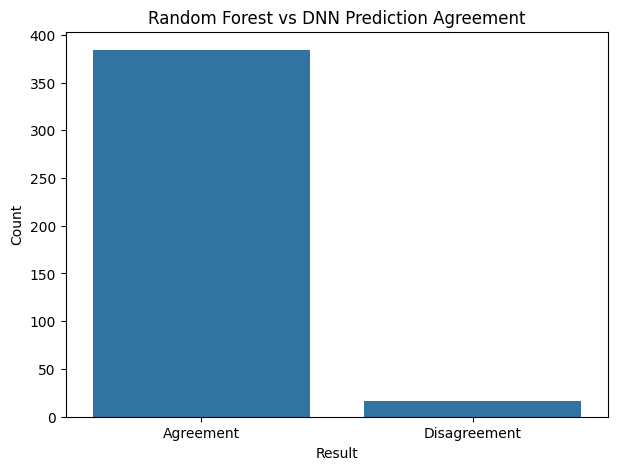

In [22]:
# ============================================================
# CELL 18 - MODEL DISAGREEMENT DETECTION
# ============================================================

model_agreement = (
    rf_pred == dnn_pred
)


agreement_rate = (
    model_agreement.mean()
)


disagreement_count = np.sum(
    ~model_agreement
)


print(
    "========== MODEL AGREEMENT ANALYSIS =========="
)


print(
    "Model Agreement:",
    round(
        agreement_rate * 100,
        2
    ),
    "%"
)


print(
    "Model Disagreement Cases:",
    disagreement_count
)


# Visualize agreement
agreement_data = pd.DataFrame({

    "Result": [

        "Agreement",

        "Disagreement"

    ],

    "Count": [

        np.sum(model_agreement),

        disagreement_count

    ]

})


plt.figure(figsize=(7,5))

sns.barplot(
    data=agreement_data,
    x="Result",
    y="Count"
)

plt.title(
    "Random Forest vs DNN Prediction Agreement"
)

plt.show()

In [23]:
# ============================================================
# CELL 19 - SECURITY ALERT SYSTEM
# ============================================================

results = X_test.copy()


results["Actual_Attack"] = (
    y_test.values
)


results["RF_Prediction"] = (
    rf_pred
)


results["DNN_Prediction"] = (
    dnn_pred
)


results["Hybrid_Prediction"] = (
    hybrid_pred
)


results["Model_Agreement"] = np.where(

    model_agreement,

    "AGREE",

    "DISAGREE"

)


results["Hybrid_Confidence"] = (

    np.max(
        hybrid_prob,
        axis=1
    ) * 100

)


# Add threat score from original dataframe
results["Threat_Behavior_Score"] = (

    df.loc[
        results.index,
        "threat_behavior_score"
    ].values

)


results["Threat_Level"] = (

    df.loc[
        results.index,
        "threat_level"
    ].values

)


def generate_alert(row):

    if row["Threat_Behavior_Score"] >= 70:

        return "CRITICAL ALERT"

    elif (

        row["Model_Agreement"] == "DISAGREE"

        and

        row["Hybrid_Confidence"] < 70

    ):

        return "REVIEW REQUIRED"

    elif (

        row["Hybrid_Prediction"] != "normal"

    ):

        return "INTRUSION DETECTED"

    else:

        return "NORMAL TRAFFIC"


results["Security_Alert"] = (

    results.apply(
        generate_alert,
        axis=1
    )

)


display(

    results[

        [

            "Actual_Attack",

            "RF_Prediction",

            "DNN_Prediction",

            "Hybrid_Prediction",

            "Threat_Behavior_Score",

            "Threat_Level",

            "Hybrid_Confidence",

            "Model_Agreement",

            "Security_Alert"

        ]

    ].head(20)

)

,Actual_Attack,RF_Prediction,DNN_Prediction,Hybrid_Prediction,Threat_Behavior_Score,Threat_Level,Hybrid_Confidence,Model_Agreement,Security_Alert
1869,normal,normal,normal,normal,4.292573,LOW,99.249100,AGREE,NORMAL TRAFFIC
1144,U2R,U2R,U2R,U2R,13.970781,LOW,99.374504,AGREE,INTRUSION DETECTED
129,normal,normal,normal,normal,11.406938,LOW,93.250023,AGREE,NORMAL TRAFFIC
1227,Probe,Probe,Probe,Probe,28.661210,LOW,90.144600,AGREE,INTRUSION DETECTED
1469,DoS,DoS,DoS,DoS,28.346435,LOW,99.416649,AGREE,INTRUSION DETECTED
1843,Probe,Probe,Probe,Probe,12.203165,LOW,91.323792,AGREE,INTRUSION DETECTED
801,Probe,Probe,Probe,Probe,13.284064,LOW,64.185295,AGREE,INTRUSION DETECTED
1560,normal,normal,normal,normal,10.873109,LOW,92.013489,AGREE,NORMAL TRAFFIC
93,normal,normal,normal,normal,13.430882,LOW,98.219360,AGREE,NORMAL TRAFFIC
2,R2L,Probe,R2L,R2L,16.940239,LOW,71.421074,DISAGREE,INTRUSION DETECTED


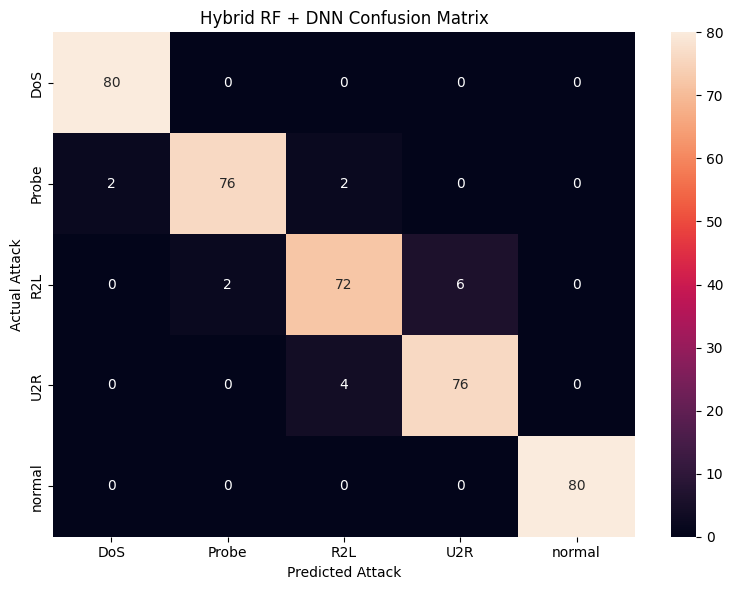

In [24]:
# ============================================================
# CELL 20 - HYBRID CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    hybrid_pred,

    labels=label_encoder.classes_

)


plt.figure(
    figsize=(8,6)
)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=(
        label_encoder.classes_
    ),

    yticklabels=(
        label_encoder.classes_
    )

)


plt.xlabel(
    "Predicted Attack"
)

plt.ylabel(
    "Actual Attack"
)

plt.title(
    "Hybrid RF + DNN Confusion Matrix"
)


plt.tight_layout()

plt.show()

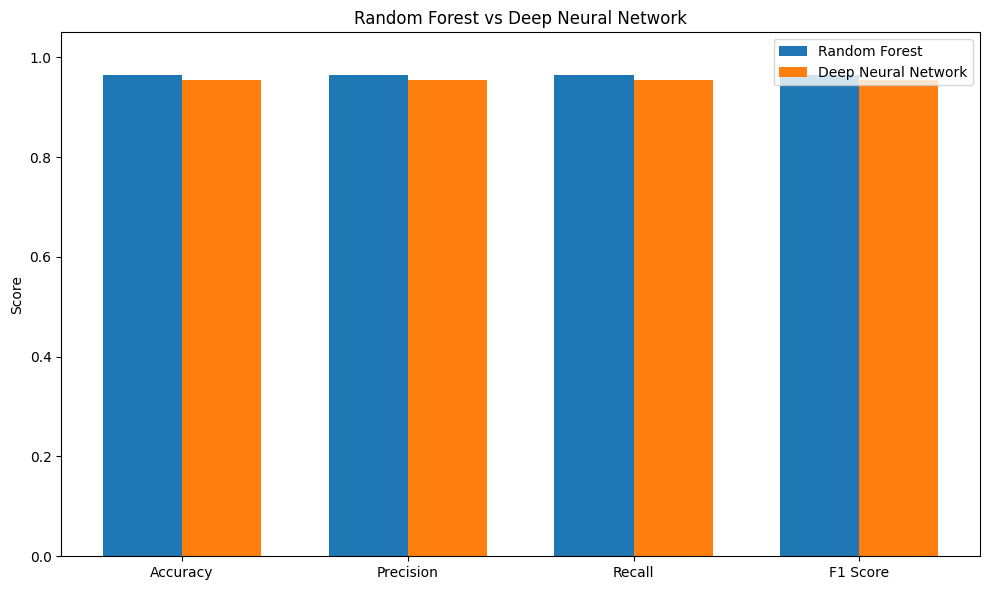

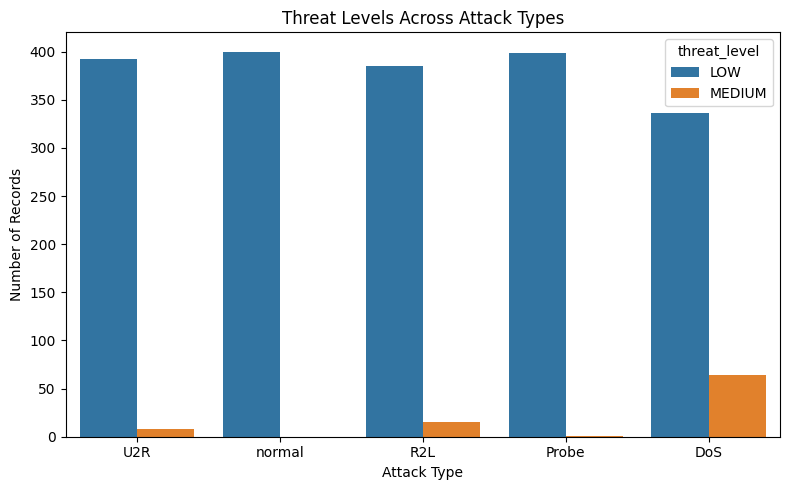


       FINAL NIDS PERFORMANCE
Random Forest Accuracy : 96.50%
DNN Accuracy           : 95.50%
Hybrid Accuracy        : 96.00%
Model Agreement        : 96.00%

Final predictions saved to:
/content/NIDS_Hybrid_Results.csv


In [25]:
# ============================================================
# CELL 21 - FINAL DASHBOARD AND SAVE RESULTS
# ============================================================

# -------------------------------
# MODEL PERFORMANCE GRAPH
# -------------------------------

metrics = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1 Score"

]


rf_values = [

    rf_accuracy,

    rf_precision,

    rf_recall,

    rf_f1

]


dnn_values = [

    dnn_accuracy,

    dnn_precision,

    dnn_recall,

    dnn_f1

]


x = np.arange(
    len(metrics)
)

width = 0.35


plt.figure(
    figsize=(10,6)
)


plt.bar(

    x - width/2,

    rf_values,

    width,

    label="Random Forest"

)


plt.bar(

    x + width/2,

    dnn_values,

    width,

    label="Deep Neural Network"

)


plt.xticks(
    x,
    metrics
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1.05
)

plt.title(
    "Random Forest vs Deep Neural Network"
)

plt.legend()

plt.tight_layout()

plt.show()


# -------------------------------
# THREAT LEVEL GRAPH
# -------------------------------

plt.figure(
    figsize=(8,5)
)


sns.countplot(

    data=df,

    x="attack_type",

    hue="threat_level"

)


plt.title(
    "Threat Levels Across Attack Types"
)

plt.xlabel(
    "Attack Type"
)

plt.ylabel(
    "Number of Records"
)

plt.tight_layout()

plt.show()


# -------------------------------
# FINAL RESULTS
# -------------------------------

print("\n====================================")
print("       FINAL NIDS PERFORMANCE")
print("====================================")

print(
    f"Random Forest Accuracy : "
    f"{rf_accuracy*100:.2f}%"
)

print(
    f"DNN Accuracy           : "
    f"{dnn_accuracy*100:.2f}%"
)

print(
    f"Hybrid Accuracy        : "
    f"{hybrid_accuracy*100:.2f}%"
)

print(
    f"Model Agreement        : "
    f"{agreement_rate*100:.2f}%"
)

print("====================================")


# -------------------------------
# SAVE RESULTS
# -------------------------------

results.to_csv(

    "/content/NIDS_Hybrid_Results.csv",

    index=False

)


print(
    "\nFinal predictions saved to:"
)

print(
    "/content/NIDS_Hybrid_Results.csv"
)